In [1]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [ ]:
import sys
!{sys.executable} -m pip install --user --force-reinstall numpy==1.26.4 matplotlib==3.9.3

In [7]:
import matplotlib
print(matplotlib.__version__)

3.10.8


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Sequential: for creating linear stack of layers <br>
Dense and Flatten: layers I will use

In [9]:
# loading pre-trained model

# Loading VGG16 model trained on ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [10]:
# creating and compiling the model
# adding new layers to base model

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')  # Change to the number of classes you have
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Creating placeholder images

In [ ]:

import os
from PIL import Image
import numpy as np

# Create directories 
os.makedirs('sample_data/class_a', exist_ok=True)
os.makedirs('sample_data/class_b', exist_ok=True)

# Create 10 sample images for each class
for i in range(10):

    # Create a blank white image for class_a
    img = Image.fromarray(np.ones((224, 224, 3), dtype=np.uint8) * 255)
    img.save(f'sample_data/class_a/img_{i}.jpg')

    # Create a blank black image for class_b
    img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    img.save(f'sample_data/class_b/img_{i}.jpg')

print("Sample images created in 'sample_data/'")


Sample images created in 'sample_data/'


Training

In [ ]:
# preprocess the dataset
train_datagen = ImageDataGenerator(rescale=1./255)
# Starts creating a data loader that reads images from folders on disk
train_generator = train_datagen.flow_from_directory(
    'sample_data', # main folder
    target_size=(224, 224), # Resizes every image to 224 x 224
    batch_size=32, # Loads 32 images at a time
    class_mode='binary'
)

# Verify if the generator has loaded images correctly
print(f"Found {train_generator.samples} images belonging to {train_generator.num_classes} classes.")

# Train the model
# from the model we defined earlier as VGG16 
if train_generator.samples > 0: # Checks that at least one image was loaded before training.
    model.fit(train_generator, epochs=10)

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.7817
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 6.3209
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 2.6817
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.8682
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 1.4993
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 1.3811
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.9279
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.4521
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.3441
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.5538


After code above, sample_data usually must look like this:<br>
sample_data/ 
  - class1/ 
    - img1.jpg
    - img2.jpg
- class2/
    - img3.jpg
    - img4.jpg

Fine-tuning the model

In [14]:
# unfreezing the top layers of the base model 

for layer in base_model.layers[-4:]:
    layer.trainable = True 

# compile the model again 
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 

# train the model again 
# from the model we defined earlier with VGG16
model.fit(train_generator, epochs=10) 

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.4895
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 4.4055
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 1.2236
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5000 - loss: 0.6537
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.6275
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.5384
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.3783
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 0.4472
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.6134
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 1.0000 - loss: 0.0745


- visualize training and validation loss<br>
- modifying training code and putting validation data<br>
- Validation data is the part of your data that the model does not train on, and is used only to check how well it is doing on unseen data during training.
  - validation_split=0.2 means 20% of the images are kept for validation
  - subset='training' uses the other 80% for learning
  - subset='validation' uses that 20% only for checking performance

Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 1.0000 - loss: 0.2661 - val_accuracy: 1.0000 - val_loss: 0.0426
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0426 - val_accuracy: 1.0000 - val_loss: 0.0178
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 1.0000 - val_loss: 0.0193
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0193 - val_accuracy: 1.0000 - val_loss: 0.0139
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 7.5004e-04
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accurac

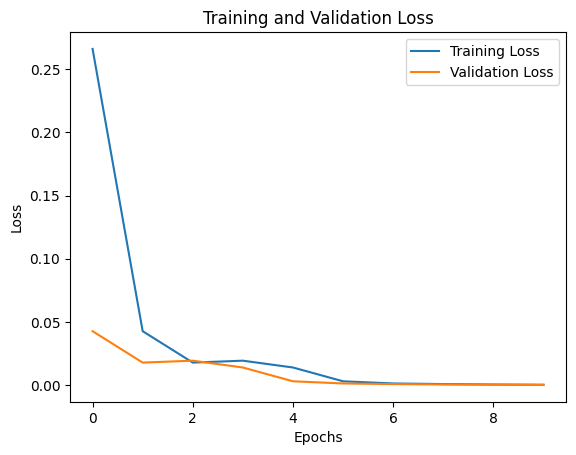

In [15]:
# Create an image data generator that rescales pixel values and reserves 20% of data for validation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create the training data loader from the training portion of the folder data
train_generator = train_datagen.flow_from_directory(
    # Read images from this main folder
    'sample_data',
    # Resize every image to 224x224
    target_size=(224, 224),
    # Load 32 images at a time
    batch_size=32,
    # Use binary labels for a 2-class problem
    class_mode='binary',
    # Use only the training split
    subset='training'
)

# Create the validation data loader from the validation portion of the same folder data
validation_generator = train_datagen.flow_from_directory(
    # Read images from this main folder
    'sample_data',
    # Resize every image to 224x224
    target_size=(224, 224),
    # Load 32 images at a time
    batch_size=32,
    # Use binary labels for a 2-class problem
    class_mode='binary',
    # Use only the validation split
    subset='validation'
)

# Train the model for 10 epochs and save the training history including validation results
history = model.fit(train_generator, epochs=10, validation_data=validation_generator)

# Plot the training loss values across epochs
plt.plot(history.history['loss'], label='Training Loss')
# Plot the validation loss values across epochs
plt.plot(history.history['val_loss'], label='Validation Loss')
# Add a title to the plot
plt.title('Training and Validation Loss')
# Label the x-axis
plt.xlabel('Epochs')
# Label the y-axis
plt.ylabel('Loss')
# Show the legend for the plotted lines
plt.legend()